<a href="https://colab.research.google.com/github/yewonhn/My-AI-Lab/blob/main/12%EC%A3%BC%EC%B0%A8/TSLA_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

교재 코드에서 일부 수정

주요 수정 및 개선 방향
1. MinMaxScaler를 통한 데이터 정규화 (필수): 데이터를 0과 1 사이의 값으로 변환하여 신경망이 안정적으로 학습할 수 있도록 해야 한다.

2. SimpleRNN 대신 LSTM 사용 (권장): 시계열 데이터 학습에 훨씬 뛰어난 성능을 보이는 LSTM(Long Short-Term Memory) 레이어로 변경.

3. 평가 방식 보완: 오차(MSE) 그래프뿐만 아니라, 실제 주가와 모델이 예측한 주가를 한눈에 비교할 수 있는 시각화 코드를 추가하면 모델의 성능을 직관적으로 파악할 수 있다.

정규화(MinMaxScaler) 작업 없이 순전파 신경망이나 RNN에 큰 숫자를 그대로 집어넣으면 모델이 중심을 잡지 못하고 방황하게 됨. 스케일링을 제대로 먼저!!

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')
raw_data = df['Close'].values.astype(float).reshape(-1, 1) # 스케일러 적용을 위해 2차원으로 변환

# [수정] 2. 데이터 정규화 (MinMaxScaler 추가)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(raw_data)

In [2]:
# 3. 시퀀스 데이터 생성 함수
def make_sample(data, window):
    train = []
    target = []
    for i in range(len(data) - window):
        train.append(data[i:i+window])
        target.append(data[i+window])
    return np.array(train), np.array(target)

window_size = 10
X, y = make_sample(scaled_data, window_size)
# X의 shape는 이미 (샘플수, window_size, 1)이 되므로 reshape 코드는 생략 가능하다고 함

In [3]:
# 4. 훈련 데이터와 테스트 데이터 분리 (8:2)
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"전체 샘플 수: {len(X)}")
print(f"훈련용 샘플 수 (X_train): {len(X_train)}")
print(f"테스트용 샘플 수 (X_test): {len(X_test)}")

전체 샘플 수: 2946
훈련용 샘플 수 (X_train): 2356
테스트용 샘플 수 (X_test): 590


In [4]:
# 5. 모델 구성 ([수정] SimpleRNN -> LSTM 변경)
model = Sequential()
model.add(Input(shape=(window_size, 1)))
model.add(LSTM(32, activation='tanh')) # 유닛 수를 조금 늘리고 LSTM 적용
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse')

- 주가는 단순히 어제, 그저께의 가격만으로 결정되지 않습니다. 일주일 전의 급락 추세나 기업의 실적 발표 등 과거의 맥락(Context)이 유지되어야 정확한 예측이 가능합니다.

SimpleRNN: 기억력이 붕어 수준이라 바로 직전 데이터에만 집착함 (예측이 단순 지연되거나 엉뚱해짐).

LSTM: 긴 시퀀스 속에서도 "중요한 과거 사건"을 골라내어 끝까지 기억함 (주가의 흐름과 패턴을 훨씬 더 잘 포착함).

In [5]:
# 6. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.0952e-04 - val_loss: 0.0022
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8824e-06 - val_loss: 0.0014
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8465e-06 - val_loss: 0.0014
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.8387e-06 - val_loss: 0.0014
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.0849e-06 - val_loss: 0.0015
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9425e-06 - val_loss: 0.0014
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.8678e-06 - val_loss: 0.0014
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6808e-06 - val_loss: 0.0014
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7022e-06 - val_loss: 0.0014
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.7244e-06 - val_loss: 0.0014
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6971e-06 - val_loss: 0.0014
Epoch 12/50
74/74 ━━━━━━━━━

Text(0.5, 1.0, 'Loss Trend')

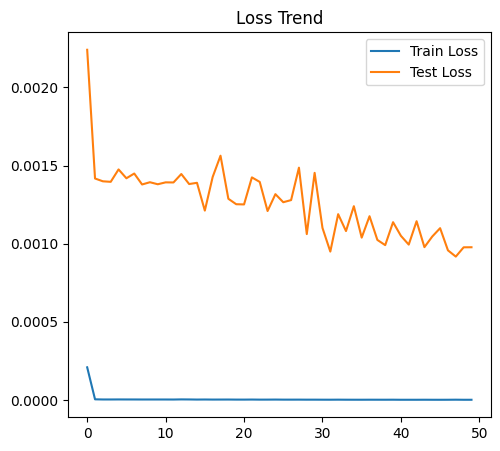

In [6]:
# 7. 그래프 시각화 (훈련 오차 vs 테스트 오차)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Test Loss")
plt.legend()
plt.title("Loss Trend")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


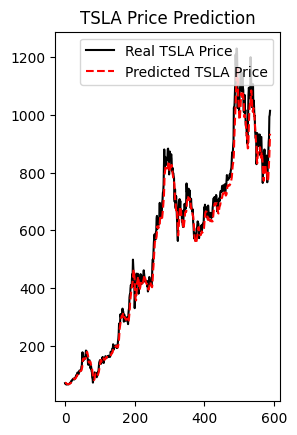

In [7]:
# [추가] 8. 실제 주가 vs 예측 주가 시각화 평가
predicted = model.predict(X_test)

# 정규화된 값을 다시 원래 주가 단위($)로 되돌림 (Inverse Transform)
real_y_test = scaler.inverse_transform(y_test)
predicted_prices = scaler.inverse_transform(predicted)

plt.subplot(1, 2, 2)
plt.plot(real_y_test, label="Real TSLA Price", color='black')
plt.plot(predicted_prices, label="Predicted TSLA Price", color='red', linestyle='--')
plt.legend()
plt.title("TSLA Price Prediction")
plt.show()